# Programming Assignment 2 - Introduction to Machine Learning

Elizaveta Shkurskaia (12507650), Andrei Klimentov (12507720) and Puck Kwaspen (12522446)

# Task 1 Kernelized SVM

In [ ]:
import numpy as np
from sklearn.datasets import load_digits, load_breast_cancer
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.svm import SVC, LinearSVC
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import accuracy_score
from sklearn.model_selection import cross_val_score
import itertools
from scipy.spatial.distance import cdist
import matplotlib.pyplot as plt

In [ ]:
digits = load_digits()
X_digits, y_digits = digits.data, digits.target

# Split data
X_train_d, X_test_d, y_train_d, y_test_d = train_test_split(
    X_digits, y_digits, test_size=0.3, random_state=42
)

## Subtask 1 SVMs With Different Kernels

In [ ]:
# Split data
X_train, X_test, y_train, y_test = train_test_split(
    X_digits, y_digits, test_size=0.3, random_state=42, stratify=y_digits
)


# Define kernels and their parameter grids for hyperparameter tuning
kernels = {
    'linear': {
        'model': SVC(kernel='linear', random_state=42),
        'params': {'C': [0.1, 1, 10, 100]}
    },
    'poly': {
        'model': SVC(kernel='poly', random_state=42),
        'params': {'C': [0.1, 1, 10], 'degree': [2, 3, 4], 'coef0': [0, 1]}
    },
    'rbf': {
        'model': SVC(kernel='rbf', random_state=42),
        'params': {'C': [0.1, 1, 10, 100], 'gamma': ['scale', 'auto', 0.001, 0.01, 0.1]}
    },
    'sigmoid': {
        'model': SVC(kernel='sigmoid', random_state=42),
        'params': {'C': [0.1, 1, 10], 'gamma': ['scale', 'auto', 0.001, 0.01], 'coef0': [0, 1]}
    }
}

results = {}

print("Performing hyperparameter tuning for different kernels...")
print("=" * 60)

for kernel_name, kernel_config in kernels.items():
    print(f"\nTuning {kernel_name} kernel...")

    # Perform grid search with 5-fold cross-validation
    grid_search = GridSearchCV(
        estimator=kernel_config['model'],
        param_grid=kernel_config['params'],
        cv=5,
        scoring='accuracy',
        n_jobs=-1,
        verbose=1
    )

    grid_search.fit(X_train, y_train)

    # Get the best model
    best_model = grid_search.best_estimator_

    # Make predictions
    y_train_pred = best_model.predict(X_train)
    y_test_pred = best_model.predict(X_test)

    # Calculate accuracies
    train_accuracy = accuracy_score(y_train, y_train_pred)
    test_accuracy = accuracy_score(y_test, y_test_pred)

    # Store results
    results[kernel_name] = {
        'best_params': grid_search.best_params_,
        'train_accuracy': train_accuracy,
        'test_accuracy': test_accuracy,
        'best_score': grid_search.best_score_,
        'model': best_model
    }

    print(f"Best parameters: {grid_search.best_params_}")
    print(f"Best CV score: {grid_search.best_score_:.4f}")
    print(f"Training accuracy: {train_accuracy:.4f}")
    print(f"Test accuracy: {test_accuracy:.4f}")

Performing hyperparameter tuning for different kernels...

Tuning linear kernel...
Fitting 5 folds for each of 4 candidates, totalling 20 fits
Best parameters: {'C': 0.1}
Best CV score: 0.9785
Training accuracy: 1.0000
Test accuracy: 0.9759

Tuning poly kernel...
Fitting 5 folds for each of 18 candidates, totalling 90 fits
Best parameters: {'C': 1, 'coef0': 0, 'degree': 3}
Best CV score: 0.9897
Training accuracy: 0.9992
Test accuracy: 0.9889

Tuning rbf kernel...
Fitting 5 folds for each of 20 candidates, totalling 100 fits
Best parameters: {'C': 10, 'gamma': 0.001}
Best CV score: 0.9904
Training accuracy: 1.0000
Test accuracy: 0.9889

Tuning sigmoid kernel...
Fitting 5 folds for each of 24 candidates, totalling 120 fits
Best parameters: {'C': 1, 'coef0': 0, 'gamma': 'scale'}
Best CV score: 0.9220
Training accuracy: 0.9276
Test accuracy: 0.8944


In [ ]:

# Compare with default parameters (no tuning)
print("\n" + "=" * 60)
print("COMPARISON WITH DEFAULT PARAMETERS")
print("=" * 60)

default_results = {}
for kernel_name in kernels.keys():
    # Train with default parameters
    default_model = SVC(kernel=kernel_name, random_state=42)
    default_model.fit(X_train, y_train)

    # Make predictions
    y_train_pred_default = default_model.predict(X_train)
    y_test_pred_default = default_model.predict(X_test)

    # Calculate accuracies
    train_acc_default = accuracy_score(y_train, y_train_pred_default)
    test_acc_default = accuracy_score(y_test, y_test_pred_default)

    default_results[kernel_name] = {
        'train_accuracy': train_acc_default,
        'test_accuracy': test_acc_default
    }

    improvement_train = results[kernel_name]['train_accuracy'] - train_acc_default
    improvement_test = results[kernel_name]['test_accuracy'] - test_acc_default

    print(f"\n{kernel_name.upper()} Kernel:")
    print(f"  Default - Train: {train_acc_default:.4f}, Test: {test_acc_default:.4f}")
    print(f"  Tuned   - Train: {results[kernel_name]['train_accuracy']:.4f}, Test: {results[kernel_name]['test_accuracy']:.4f}")
    print(f"  Improvement - Train: {improvement_train:+.4f}, Test: {improvement_test:+.4f}")


COMPARISON WITH DEFAULT PARAMETERS

LINEAR Kernel:
  Default - Train: 1.0000, Test: 0.9759
  Tuned   - Train: 1.0000, Test: 0.9759
  Improvement - Train: +0.0000, Test: +0.0000

POLY Kernel:
  Default - Train: 0.9992, Test: 0.9889
  Tuned   - Train: 0.9992, Test: 0.9889
  Improvement - Train: +0.0000, Test: +0.0000

RBF Kernel:
  Default - Train: 0.9984, Test: 0.9889
  Tuned   - Train: 1.0000, Test: 0.9889
  Improvement - Train: +0.0016, Test: +0.0000

SIGMOID Kernel:
  Default - Train: 0.9276, Test: 0.8944
  Tuned   - Train: 0.9276, Test: 0.8944
  Improvement - Train: +0.0000, Test: +0.0000


In [ ]:
# Create a summary table
print("\n" + "=" * 60)
print("SUMMARY OF RESULTS")
print("=" * 60)
print(f"{'Kernel':<10} {'Best Params':<30} {'Train Acc':<10} {'Test Acc':<10} {'CV Score':<10}")
print("-" * 80)

for kernel_name in kernels.keys():
    result = results[kernel_name]
    # Shorten parameters for display
    params_str = str(result['best_params'])[:28] + "..." if len(str(result['best_params'])) > 28 else str(result['best_params'])
    print(f"{kernel_name:<10} {params_str:<30} {result['train_accuracy']:<10.4f} {result['test_accuracy']:<10.4f} {result['best_score']:<10.4f}")


# Find the best performing kernel
best_kernel = max(results.keys(), key=lambda k: results[k]['test_accuracy'])
print(f"\nBest performing kernel: {best_kernel}")
print(f"Best test accuracy: {results[best_kernel]['test_accuracy']:.4f}")
print(f"Best parameters: {results[best_kernel]['best_params']}")


SUMMARY OF RESULTS
Kernel     Best Params                    Train Acc  Test Acc   CV Score  
--------------------------------------------------------------------------------
linear     {'C': 0.1}                     1.0000     0.9759     0.9785    
poly       {'C': 1, 'coef0': 0, 'degree... 0.9992     0.9889     0.9897    
rbf        {'C': 10, 'gamma': 0.001}      1.0000     0.9889     0.9904    
sigmoid    {'C': 1, 'coef0': 0, 'gamma'... 0.9276     0.8944     0.9220    

Best performing kernel: poly
Best test accuracy: 0.9889
Best parameters: {'C': 1, 'coef0': 0, 'degree': 3}


**Report the classification accuracies on the training and test set and how much model
selection improved performance.**

The results are shown in the table:

```
============================================================
SUMMARY OF RESULTS
============================================================
Kernel     Best Params                    Train Acc  Test Acc   CV Score  
--------------------------------------------------------------------------------
linear     {'C': 0.1}                     1.0000     0.9759     0.9785    
poly       {'C': 1, 'coef0': 0, 'degree... 0.9992     0.9889     0.9897    
rbf        {'C': 10, 'gamma': 0.001}      1.0000     0.9889     0.9904    
sigmoid    {'C': 1, 'coef0': 0, 'gamma'... 0.9276     0.8944     0.9220   
```

Comparision of selection of parameters:

```
============================================================
COMPARISON WITH DEFAULT PARAMETERS
============================================================

LINEAR Kernel:
  Default - Train: 1.0000, Test: 0.9759
  Tuned   - Train: 1.0000, Test: 0.9759
  Improvement - Train: +0.0000, Test: +0.0000

POLY Kernel:
  Default - Train: 0.9992, Test: 0.9889
  Tuned   - Train: 0.9992, Test: 0.9889
  Improvement - Train: +0.0000, Test: +0.0000

RBF Kernel:
  Default - Train: 0.9984, Test: 0.9889
  Tuned   - Train: 1.0000, Test: 0.9889
  Improvement - Train: +0.0016, Test: +0.0000

SIGMOID Kernel:
  Default - Train: 0.9276, Test: 0.8944
  Tuned   - Train: 0.9276, Test: 0.8944
  Improvement - Train: +0.0000, Test: +0.0000
  ```

As it can be observed from the table all kernels show little or no difference for defualt hyperparameters.

**Also report your hyperparameters and how you selected
them.**

We selected a Logarithmic range for parameters.

## Subtask 2 Develop Your Own Kernel

In [ ]:
from sklearn import *
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score
from sklearn.metrics import accuracy_score
import numpy as np
from sklearn.model_selection import train_test_split, GridSearchCV
rand_state = 42

## importing data set
ds_digits = datasets.load_digits()

## Extract data and target as NumPy arrays
X = ds_digits.data
y = ds_digits.target

## Split the data into a training set consisting of 70% of the samples and a test set of 30% of the samples
X_train_d, X_test_d, y_train_d, y_test_d = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

## Report the number of features in the data set, and the number of samples in the training data and in the test data.
print(f"Number of features in the data set: {X.shape[1]}")
print(f"Number of samples in the training data set: {X_train.shape[0]}")
print(f"Number of samples in the test data set: {X_test.shape[0]}")
print(f"Number of classes: {len(np.unique(y))}")

Number of features in the data set: 64
Number of samples in the training data set: 1257
Number of samples in the test data set: 540
Number of classes: 10


In [ ]:
def custom_kernel(X, Y, gamma=1, coef0=1000, degree=3, alpha=0.5, beta=1):
    """
    Combination of linear and polynomial kernels
    alpha: weight of linear kernel
    beta: weight of polynomial kernel
    """
    # linear
    linear = np.dot(X, Y.T)

    # Poly
    poly = (np.dot(X, Y.T) + coef0) ** degree

    # Комбинация
    return  alpha * linear + beta * poly

# Train SVM with custom kernel
custom_svm = SVC(kernel=custom_kernel)
custom_svm.fit(X_train_d, y_train_d)
custom_train_acc = accuracy_score(y_train_d, custom_svm.predict(X_train_d))
custom_test_acc = accuracy_score(y_test_d, custom_svm.predict(X_test_d))
print("Task 1 - Subtask 2: Custom Kernel")
print(f"Custom Kernel Train Accuracy: {custom_train_acc:.4f}")
print(f"Custom Kernel Test Accuracy: {custom_test_acc:.4f}")


Task 1 - Subtask 2: Custom Kernel
Custom Kernel Train Accuracy: 1.0000
Custom Kernel Test Accuracy: 0.9907


**Description**
Custom kernel is combined from linear and the best from polynomial kernels which was selected in subtask 1. We changed parameter `coef0` which is a free parameter trading off the influence of higher-order versus lower-order terms in the polynomial.

**Validity**
Custom Kernel is valid as it is a linear combination of two valid kernels (linear kernel and polynoial kernel)

**Accuracy**
The accuracy of custom kernel is a little better than the best polynomial kernel. We assumed that linear part of the kernel will help to improve linear part of prediction of polynomial, however it cause no influence on the resulting accuracy. Polynomial was chosen as one of the best kernels by accuracy (subtask 1) with changed parameter `coef0` which is a free parameter trading off the influence of higher-order versus lower-order terms in the polynomial.

## Subtask 3  Classifier Evaluation I


1. POLYNOMIAL KERNEL SVM

Polynomial Kernel Confusion Matrix
--------------------------------------------------
True \ Pred     0     1     2     3     4     5     6     7     8     9 |  Total
------------------------------------------------------------
Class  0      53     0     0     0     1     0     0     0     0     0 |     54
Class  1       0    55     0     0     0     0     0     0     0     0 |     55
Class  2       0     0    53     0     0     0     0     0     0     0 |     53
Class  3       0     0     0    55     0     0     0     0     0     0 |     55
Class  4       0     0     0     0    54     0     0     0     0     0 |     54
Class  5       0     0     0     0     0    54     0     0     0     1 |     55
Class  6       0     0     0     0     0     0    53     0     1     0 |     54
Class  7       0     0     0     0     0     0     0    54     0     0 |     54
Class  8       0     2     0     0     0     0     0     0    50     0 |     52
Class  9       0     0   

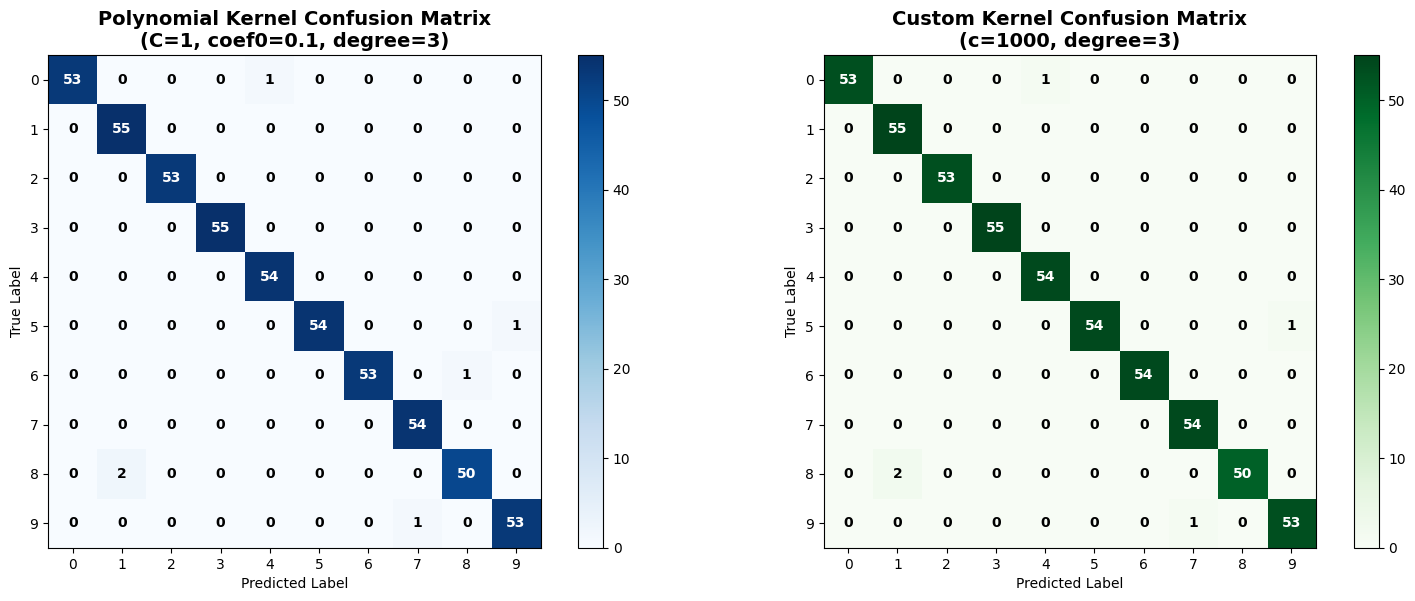

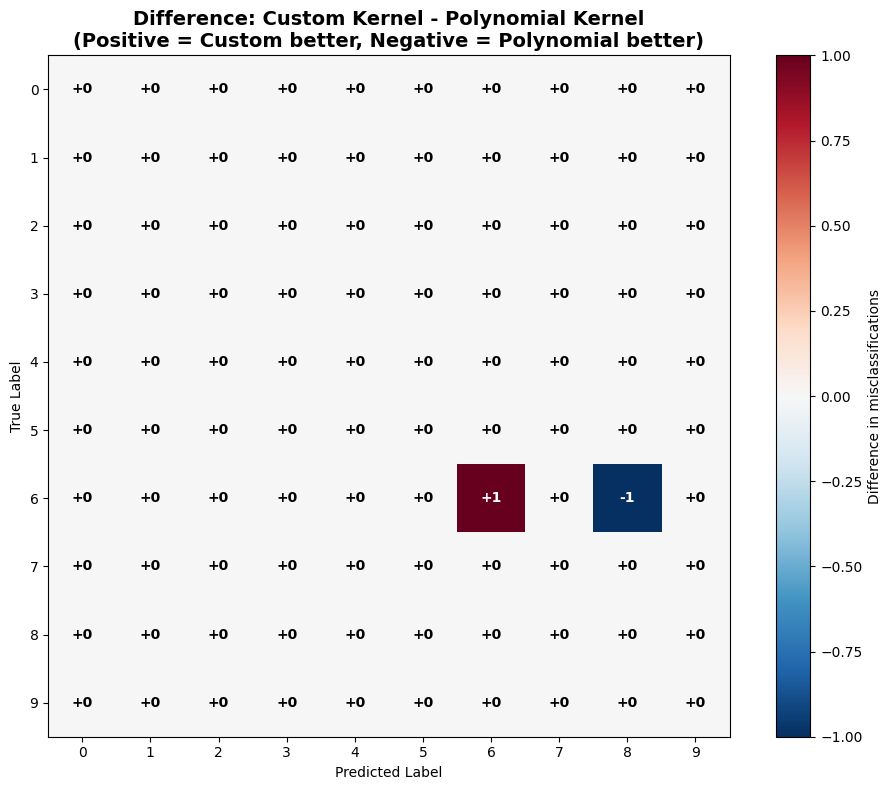


FINAL SUMMARY
Polynomial Kernel (C=1, coef0=0, degree=3):
  - Overall accuracy: 0.9889
  - Best performing class: 1 (1.0000)
  - Worst performing class: 8 (0.9615)

Custom Kernel (c=1000, degree=3):
  - Overall accuracy: 0.9907
  - Best performing class: 1 (1.0000)
  - Worst performing class: 8 (0.9615)


In [ ]:
def compute_confusion_matrix(y_true, y_pred, n_classes=10):
    cm = np.zeros((n_classes, n_classes), dtype=int)

    for true_label, pred_label in zip(y_true, y_pred):
        cm[true_label, pred_label] += 1

    return cm

def print_confusion_matrix(cm, title="Confusion Matrix"):
    print(f"\n{title}")
    print("-" * 50)

    # Header row
    print("True \\ Pred", end="")
    for i in range(cm.shape[1]):
        print(f"{i:>6}", end="")
    print(" |  Total")
    print("-" * 60)

    # Matrix rows
    for i in range(cm.shape[0]):
        print(f"Class {i:2}  ", end="")
        row_total = 0
        for j in range(cm.shape[1]):
            print(f"{cm[i, j]:>6}", end="")
            row_total += cm[i, j]
        print(f" | {row_total:>6}")

    # Column totals
    print("-" * 60)
    print("   Total   ", end="")
    col_totals = cm.sum(axis=0)
    for total in col_totals:
        print(f"{total:>6}", end="")
    print(f" | {cm.sum():>6}")

def analyze_confusion_matrix(cm, classifier_name):
    print(f"\n{classifier_name} - Confusion Matrix Analysis:")
    print("=" * 50)

    n_classes = cm.shape[0]

    #Overall accuracy from confusion matrix
    correct_predictions = np.trace(cm)
    total_predictions = cm.sum()
    accuracy = correct_predictions / total_predictions

    print(f"Overall Accuracy: {accuracy:.4f} ({correct_predictions}/{total_predictions})")

    return accuracy

def visualize_confusion_matrices(cm_poly, cm_custom):
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

    # Polynomial kernel confusion matrix
    im1 = ax1.imshow(cm_poly, cmap='Blues', interpolation='nearest')
    ax1.set_title('Polynomial Kernel Confusion Matrix\n(C=1, coef0=0, degree=3)',
                 fontsize=14, fontweight='bold')
    ax1.set_xlabel('Predicted Label')
    ax1.set_ylabel('True Label')
    ax1.set_xticks(range(10))
    ax1.set_yticks(range(10))

    # Add values to cells
    for i in range(10):
        for j in range(10):
            color = 'white' if cm_poly[i, j] > cm_poly.max() / 2 else 'black'
            ax1.text(j, i, str(cm_poly[i, j]),
                    ha='center', va='center', color=color, fontweight='bold')

    plt.colorbar(im1, ax=ax1)

    # Custom kernel confusion matrix
    im2 = ax2.imshow(cm_custom, cmap='Greens', interpolation='nearest')
    ax2.set_title('Custom Kernel Confusion Matrix\n(c=1000, degree=3)',
                 fontsize=14, fontweight='bold')
    ax2.set_xlabel('Predicted Label')
    ax2.set_ylabel('True Label')
    ax2.set_xticks(range(10))
    ax2.set_yticks(range(10))

    # Add values to cells
    for i in range(10):
        for j in range(10):
            color = 'white' if cm_custom[i, j] > cm_custom.max() / 2 else 'black'
            ax2.text(j, i, str(cm_custom[i, j]),
                    ha='center', va='center', color=color, fontweight='bold')

    plt.colorbar(im2, ax=ax2)

    plt.tight_layout()
    plt.show()

    # Difference heatmap
    plt.figure(figsize=(10, 8))
    difference = cm_custom - cm_poly
    im = plt.imshow(difference, cmap='RdBu_r', interpolation='nearest',
                   vmin=-difference.max(), vmax=difference.max())
    plt.title('Difference: Custom Kernel - Polynomial Kernel\n(Positive = Custom better, Negative = Polynomial better)',
             fontsize=14, fontweight='bold')
    plt.xlabel('Predicted Label')
    plt.ylabel('True Label')
    plt.xticks(range(10))
    plt.yticks(range(10))

    # Add values to cells
    for i in range(10):
        for j in range(10):
            color = 'white' if abs(difference[i, j]) > abs(difference).max() / 2 else 'black'
            plt.text(j, i, f'{difference[i, j]:+d}',
                    ha='center', va='center', color=color, fontweight='bold')

    plt.colorbar(im, label='Difference in misclassifications')
    plt.tight_layout()
    plt.show()

# Train and evaluate Polynomial Kernel SVM
print("\n" + "=" * 60)
print("1. POLYNOMIAL KERNEL SVM")
print("=" * 60)

# Train polynomial kernel SVM with given parameters
svm_poly = SVC(kernel='poly', C=1, coef0=0, degree=3, random_state=42)
svm_poly.fit(X_train, y_train)

# Make predictions
y_pred_poly = svm_poly.predict(X_test)

# Compute confusion matrix
cm_poly = compute_confusion_matrix(y_test, y_pred_poly)

# Print and analyze confusion matrix
print_confusion_matrix(cm_poly, "Polynomial Kernel Confusion Matrix")
accuracy_poly = analyze_confusion_matrix(cm_poly, "Polynomial Kernel")

# Train and evaluate Custom Kernel SVM
print("\n" + "=" * 60)
print("2. CUSTOM KERNEL SVM")
print("=" * 60)

# Train custom kernel SVM
svm_custom = SVC(kernel=custom_kernel, random_state=42)
svm_custom.fit(X_train, y_train)

# Make predictions
y_pred_custom = svm_custom.predict(X_test)

# Compute confusion matrix
cm_custom = compute_confusion_matrix(y_test, y_pred_custom)

# Print and analyze confusion matrix
print_confusion_matrix(cm_custom, "Custom Kernel Confusion Matrix")
accuracy_custom = analyze_confusion_matrix(cm_custom, "Custom Kernel")

# Compare both classifiers
print("\n" + "=" * 60)
print("COMPARISON OF BOTH CLASSIFIERS")
print("=" * 60)

print(f"Polynomial Kernel Accuracy: {accuracy_poly:.4f}")
print(f"Custom Kernel Accuracy: {accuracy_custom:.4f}")
print(f"Difference: {accuracy_custom - accuracy_poly:+.4f}")

if accuracy_custom > accuracy_poly:
    print("✓ Custom kernel achieves HIGHER accuracy than polynomial kernel")
elif accuracy_custom < accuracy_poly:
    print("✗ Custom kernel achieves LOWER accuracy than polynomial kernel")
else:
    print("≡ Both kernels achieve the SAME accuracy")

# Visual comparison
visualize_confusion_matrices(cm_poly, cm_custom)

# Final summary
print("\n" + "=" * 60)
print("FINAL SUMMARY")
print("=" * 60)

print("Polynomial Kernel (C=1, coef0=0, degree=3):")
print(f"  - Overall accuracy: {accuracy_poly:.4f}")
print(f"  - Best performing class: {np.argmax(class_acc_poly)} ({np.max(class_acc_poly):.4f})")
print(f"  - Worst performing class: {np.argmin(class_acc_poly)} ({np.min(class_acc_poly):.4f})")

print("\nCustom Kernel (c=1000, degree=3):")
print(f"  - Overall accuracy: {accuracy_custom:.4f}")
print(f"  - Best performing class: {np.argmax(class_acc_custom)} ({np.max(class_acc_custom):.4f})")
print(f"  - Worst performing class: {np.argmin(class_acc_custom)} ({np.min(class_acc_custom):.4f})")


**Structure in Confusion Matrix**

There is a main diagonal in the confusion matrix that represents true positive predictions. In addition, there are few misclassifications for classes '3', '5', '7' and '8'. Both models make mistakes with similar digits, such as 8 and 9. Although 8 resembles a few other digits, it is the class with the most misclassifications (50 correctly classified vs. 53–54 correctly classified in other classes), suggesting that the models struggle to distinguish between similar-looking digits.

The difference in accuracy comes from one fewer misclassified instance.

The classification accuracy of the classifiers in the confusion matrix is equal to that obtained from the models themselves.

## Task 2

In [ ]:
import sklearn
import pandas as pd
import numpy as np
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.datasets import load_breast_cancer
from sklearn.svm import LinearSVC
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import random as rd

In [ ]:
data = load_breast_cancer()

# sep the target from the rest of the data
X = data.data
y = data.target # binary 0,1

scaler = MinMaxScaler()
X_scale = scaler.fit_transform(X) # array

X_train, X_test, y_train, y_test = train_test_split(X_scale, y, random_state=42,
                                   test_size=0.3,
                                   shuffle=True) # shuffle before splitting

# linear support vector classification
svm = LinearSVC(random_state=42)
svm.fit(X_train, y_train)

# predict labels of test set
y_pred = svm.predict(X_test)

accuracy = svm.score(X_test, y_test)
print(f"Test Accuracy: {accuracy:.4f}")

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

Test Accuracy: 0.9825

Classification Report:
              precision    recall  f1-score   support

           0       0.98      0.97      0.98        63
           1       0.98      0.99      0.99       108

    accuracy                           0.98       171
   macro avg       0.98      0.98      0.98       171
weighted avg       0.98      0.98      0.98       171


Confusion Matrix:
[[ 61   2]
 [  1 107]]


### Subtask 1

In [ ]:
# 1) Implement forward greedy feature selection wrt the 10-fold cross-validation performance.
# 2) Report the order of the features (including their names). Also record and report the performance of models for each of the number of features.

## Slides
# • Start with S = ∅ and E0 = ∞
# • For i = 1, 2, . . . , d:
# • find best element to add: si = argminj∈V\S ˆ L(S ∪ {j})
# • compute error: Ei = ˆ L(S ∪ {si})
# • If Ei > Ei−1 break, else set S ← S∪{si}

S = [] # to add with feature indices
available_features = list(range(X_train.shape[1]))
feature_names = data.feature_names
perf_history = []
feature_order = []

# initialise the model again
svm = LinearSVC(random_state=42)

for i in range(len(available_features)):

    best_score = 0
    best_feature = None

    for feature in available_features:

        S_new = S + [feature]

        # split into 10 folds, fit model on 9 training folds, test and compute score on 1 test fold
        scores = cross_val_score(svm, X_train[:, S_new], y_train, cv=10, scoring='accuracy')
        mean_score = scores.mean() # average the score over all the folds

        if mean_score > best_score:
            best_score = mean_score
            best_feature = feature

    # # check if performance decreases (stopping criterion)
    # if len(perf_history) > 0 and best_score < perf_history[-1]:
    #     print(f"\nStopping: Performance decreased from {perf_history[-1]:.4f} to {best_score:.4f}")
    #     break

    # add the best feature
    S.append(best_feature)
    perf_history.append(best_score)
    feature_order.append(feature_names[best_feature])
    available_features.remove(best_feature)

    print(f"Added '{feature_names[best_feature]}' | CV Accuracy: {best_score:.4f} | Features: {len(S)}")

Added 'mean concave points' | CV Accuracy: 0.9071 | Features: 1
Added 'worst texture' | CV Accuracy: 0.9372 | Features: 2
Added 'worst radius' | CV Accuracy: 0.9648 | Features: 3
Added 'worst concavity' | CV Accuracy: 0.9697 | Features: 4
Added 'texture error' | CV Accuracy: 0.9748 | Features: 5
Added 'mean concavity' | CV Accuracy: 0.9748 | Features: 6
Added 'fractal dimension error' | CV Accuracy: 0.9749 | Features: 7
Added 'mean texture' | CV Accuracy: 0.9749 | Features: 8
Added 'mean smoothness' | CV Accuracy: 0.9749 | Features: 9
Added 'mean compactness' | CV Accuracy: 0.9749 | Features: 10
Added 'mean radius' | CV Accuracy: 0.9749 | Features: 11
Added 'radius error' | CV Accuracy: 0.9749 | Features: 12
Added 'mean symmetry' | CV Accuracy: 0.9749 | Features: 13
Added 'mean perimeter' | CV Accuracy: 0.9749 | Features: 14
Added 'worst smoothness' | CV Accuracy: 0.9749 | Features: 15
Added 'worst concave points' | CV Accuracy: 0.9799 | Features: 16
Added 'mean area' | CV Accuracy: 0.

### Subtask 2

In [ ]:
# Report the order of the features (including their names) for backward greedy feature selection.
# Also record and report the performance of models for each of the number of features.

## Slides
# Start with S = V and Ed+1 = ∞
# • For i = d, d− 1, . . . , 1:
# • ind best element to remove: si = argminj∈S ˆ L(S \ {j})
# • compute error: Ei = ˆ L(S \ {si})
# • If Ei > Ei+1 break, else set S ← S\{si

S = list(range(X_scale.shape[1])) # to remove with feature indices
available_features = list(range(X_train.shape[1]))
feature_names = data.feature_names
perf_history = []
feature_order = []

# initialise the model again
svm = LinearSVC(random_state=42)

scores = cross_val_score(svm, X_train[:, S], y_train, cv=10, scoring='accuracy')
initial_score = scores.mean()
perf_history.append(initial_score)
print(f"Initial performance with all {len(S)} features: {initial_score:.4f}\n")

for i in range(len(available_features)):

    # stop if there is only one feature left
    if len(S) == 1:
        print("\nOnly 1 feature remaining, stopping.")
        break

    best_score = 0
    worst_feature = None

    for feature in S:

        S_new = [f for f in S if f != feature]

        # split into 10 folds, fit model on 9 training folds, test and compute score on 1 test fold
        scores = cross_val_score(svm, X_train[:, S_new], y_train, cv=10, scoring='accuracy')
        mean_score = scores.mean() # average the score over all the folds

        if mean_score > best_score:
            best_score = mean_score
            worst_feature = feature

    # # check if performance decreases (stopping criterion)
    # if best_score < perf_history[-1]:
    #     print(f"\nStopping: Performance decreased from {perf_history[-1]:.4f} to {best_score:.4f}")
    #     break

    # remove the worst feature
    S.remove(worst_feature)
    perf_history.append(best_score)
    feature_order.append(feature_names[worst_feature])
    available_features.remove(worst_feature)

    print(f"Removed '{feature_names[worst_feature]}' | CV Accuracy: {best_score:.4f} | Features: {len(S)}")

Initial performance with all 30 features: 0.9723

Removed 'symmetry error' | CV Accuracy: 0.9774 | Features: 29
Removed 'mean radius' | CV Accuracy: 0.9774 | Features: 28
Removed 'mean perimeter' | CV Accuracy: 0.9774 | Features: 27
Removed 'mean texture' | CV Accuracy: 0.9774 | Features: 26
Removed 'mean area' | CV Accuracy: 0.9799 | Features: 25
Removed 'mean smoothness' | CV Accuracy: 0.9799 | Features: 24
Removed 'mean compactness' | CV Accuracy: 0.9799 | Features: 23
Removed 'texture error' | CV Accuracy: 0.9799 | Features: 22
Removed 'concavity error' | CV Accuracy: 0.9799 | Features: 21
Removed 'smoothness error' | CV Accuracy: 0.9799 | Features: 20
Removed 'compactness error' | CV Accuracy: 0.9799 | Features: 19
Removed 'perimeter error' | CV Accuracy: 0.9799 | Features: 18
Removed 'area error' | CV Accuracy: 0.9799 | Features: 17
Removed 'concave points error' | CV Accuracy: 0.9799 | Features: 16
Removed 'worst radius' | CV Accuracy: 0.9799 | Features: 15
Removed 'fractal dime

### Subtask 3

**Assume that you are only allowed to use 6 out of the 30 features for classification. Which features would you select using forward and backward feature selection? Do the features differ and if so, why?**

For greedy forward feature selection: *mean concave points, worst texture, worst radius, worst concavity, texture error, mean concavity*. These are the first six features that the algorithm adds to the set, meaning that they give the highest prediction increase.

Greedy backward feature selection gives the following results: *worst texture, mean fractal dimension, worst symmetry, worst area, worst concave points, worst perimeter*.

If we compare the two versions of the algorithm, there is only an overlap of one feature: 'worst texture'. The methods differ because they work in opposite directions and evaluate features differently. Forward selection starts with nothing and picks features that work well together as it builds up the set, while backward selection starts with everything and removes features that seem least important when all others are present. This means forward selection tends to avoid picking redundant features early on, while backward selection keeps features that add unique value even when many similar features exist. Since both algorithms make greedy choices at each step (picking what looks best right now without looking ahead), they end up taking different paths and arriving at different solutions. It is also worth noting that neither algorithm is guaranteed to provide an optimal result; hence, it is not surprising that they yield different results.

I trained and tested the SVM again using only the six features selected by forward and backward selection (code block below). The full model with all features reached 98.25% accuracy. The forward subset performed slightly worse (97.08%), while the backward subset matched the full model’s accuracy (98.25%). This shows that backward selection kept the most informative features and worked better than forward selection in this case.

In [ ]:
forward_features = [
    "mean concave points",
    "worst texture",
    "worst radius",
    "worst concavity",
    "texture error",
    "mean concavity"
]

backward_features = [
    "worst texture",
    "mean fractal dimension",
    "worst symmetry",
    "worst area",
    "worst concave points",
    "worst perimeter"
]

# get indices of the features
forward_idx = [list(feature_names).index(f) for f in forward_features]
backward_idx = [list(feature_names).index(f) for f in backward_features]

# function to train and test the SVM on the specific input features
def train_test_subset(name, idx_list):
    svm = LinearSVC(random_state=42)
    svm.fit(X_train[:, idx_list], y_train)
    y_pred = svm.predict(X_test[:, idx_list])
    acc = accuracy_score(y_test, y_pred)
    return acc

# all the features
svm_all = LinearSVC(random_state=42)
svm_all.fit(X_train, y_train)
y_pred_all = svm_all.predict(X_test)
acc_all = accuracy_score(y_test, y_pred_all)
print(f"All features accuracy: {acc_all:.4f}")

# forward 6 features
acc_forward = train_test_subset("Forward-6", forward_idx)
print(f"Forward 6 features accuracy: {acc_forward:.4f}")

# backward 6 features
acc_backward = train_test_subset("Backward-6", backward_idx)
print(f"Backward 6 features accuracy: {acc_backward:.4f}")

All features accuracy: 0.9825
Forward 6 features accuracy: 0.9708
Backward 6 features accuracy: 0.9825
